# Notebook 02b-UNSW — DNN 5-class diagnostic (learning curves)

**Purpose:** The DNN 5-class model came out weaker than RF/XGB on UNSW-NB15 (F1-macro 0.51 vs 0.52/0.58). This notebook investigates whether it's undertraining, overfitting, or a deeper architectural issue, before deciding to retune.

**What this notebook does:**

1. Retrains the 5-class DNN with **verbose per-epoch logging** of train loss, val loss, val accuracy, and **per-class val F1** (including U2R)
2. Plots learning curves
3. Diagnoses: is val loss still dropping at the early-stop point? Does U2R F1 plateau early or keep improving? Is there overfitting (train acc >> val acc)?
4. Outputs a clear recommendation

**This does not overwrite the existing `dnn_5class_smote` model.** Diagnostic only.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os, shutil
shutil.copy('/content/drive/MyDrive/XIDS_Research/.gitconfig',       '/root/.gitconfig')
shutil.copy('/content/drive/MyDrive/XIDS_Research/.git-credentials', '/root/.git-credentials')

PROJECT_DIR = '/content/drive/MyDrive/XIDS_Research/xids-research'
os.chdir(PROJECT_DIR)

!nvidia-smi -L
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

GPU 0: Tesla T4 (UUID: GPU-dfe1c1b4-561e-df87-0164-c863b6157eae)
Device: cuda


In [3]:
import numpy as np
import json
from pathlib import Path
from collections import Counter

REPO     = Path(PROJECT_DIR)
PROC_DIR = REPO / 'data/processed/unsw_nb15'

X_train = np.load(PROC_DIR / 'X_train.npy')
X_test  = np.load(PROC_DIR / 'X_test.npy')
y_train_5class = np.load(PROC_DIR / 'y_train_5class.npy')
y_test_5class  = np.load(PROC_DIR / 'y_test_5class.npy')

FIVE_CLASS_NAMES = ['Normal', 'DoS', 'Probe', 'R2L', 'U2R']

# Apply SMOTE exactly as Notebook 02 did
from imblearn.over_sampling import SMOTE
pre = Counter(y_train_5class)
largest_attack = max(pre[c] for c in [1, 2, 3, 4])
sampling_strategy = {0: pre[0]}
for c in [1, 2, 3, 4]:
    sampling_strategy[c] = max(pre[c], largest_attack)

smote = SMOTE(sampling_strategy=sampling_strategy, random_state=42, k_neighbors=5)
X_train_sm, y_train_5class_sm = smote.fit_resample(X_train, y_train_5class)
X_train_sm = X_train_sm.astype(np.float32)

print(f'SMOTE done: {X_train_sm.shape}')
print(f'Test set: {X_test.shape}')

SMOTE done: (269292, 196)
Test set: (63461, 196)


## Train DNN with full diagnostic logging

Same architecture, same hyperparameters as Notebook 02 — but:
- 60 epochs max (vs 40 in Notebook 02), to see if val loss is still dropping past 40
- Patience increased to 10 (vs 5), to avoid premature stopping on a noisy val curve
- **Test-set F1-macro and U2R F1 logged every epoch** alongside val loss — gives us the full picture

Note: logging test metrics each epoch is a diagnostic shortcut, **not** how we'd select a model for the paper. We're only doing this to see what the learning curve looks like.

In [4]:
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import f1_score
import time

class XIDSMLP(nn.Module):
    def __init__(self, n_features, n_classes, p_drop=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(p_drop),
            nn.Linear(256, 128),        nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(p_drop),
            nn.Linear(128, 64),         nn.BatchNorm1d(64),  nn.ReLU(), nn.Dropout(p_drop),
            nn.Linear(64, 32),          nn.BatchNorm1d(32),  nn.ReLU(), nn.Dropout(p_drop),
            nn.Linear(32, n_classes),
        )
    def forward(self, x):
        return self.net(x)

torch.manual_seed(42)

# Stratified 90/10 split (matches Notebook 02 exactly)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_sm, y_train_5class_sm, test_size=0.1, random_state=42, stratify=y_train_5class_sm,
)

Xt  = torch.tensor(X_tr,  dtype=torch.float32)
yt  = torch.tensor(y_tr,  dtype=torch.long)
Xv  = torch.tensor(X_val, dtype=torch.float32).to(device)
yv  = torch.tensor(y_val, dtype=torch.long).to(device)
Xte = torch.tensor(X_test, dtype=torch.float32).to(device)

loader = DataLoader(TensorDataset(Xt, yt), batch_size=512, shuffle=True)

model = XIDSMLP(X_train_sm.shape[1], n_classes=5).to(device)
opt   = torch.optim.Adam(model.parameters(), lr=1e-3)

cw = compute_class_weight('balanced', classes=np.arange(5), y=y_train_5class_sm)
cw_tensor = torch.tensor(cw, dtype=torch.float32, device=device)
criterion = nn.CrossEntropyLoss(weight=cw_tensor)
print(f'Class weights (post-SMOTE): {dict(zip(FIVE_CLASS_NAMES, cw.round(3)))}')

history = {
    'epoch': [], 'train_loss': [], 'val_loss': [], 'val_acc': [],
    'test_f1_macro': [], 'test_u2r_f1': [], 'test_acc': [],
}

EPOCHS = 60
PATIENCE = 10
best_val = float('inf')
best_epoch = 0
no_improve = 0

t0 = time.time()
for ep in range(1, EPOCHS + 1):
    model.train()
    train_losses = []
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        opt.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        opt.step()
        train_losses.append(loss.item())

    model.eval()
    with torch.no_grad():
        val_logits = model(Xv)
        val_loss   = criterion(val_logits, yv).item()
        val_acc    = (val_logits.argmax(1) == yv).float().mean().item()

        test_logits = model(Xte)
        test_pred   = test_logits.argmax(1).cpu().numpy()
        test_acc    = (test_pred == y_test_5class).mean()
        test_f1m    = f1_score(y_test_5class, test_pred, average='macro', zero_division=0)
        per_class   = f1_score(y_test_5class, test_pred, labels=range(5), average=None, zero_division=0)
        test_u2r    = per_class[4]

    history['epoch'].append(ep)
    history['train_loss'].append(float(np.mean(train_losses)))
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['test_acc'].append(float(test_acc))
    history['test_f1_macro'].append(float(test_f1m))
    history['test_u2r_f1'].append(float(test_u2r))

    flag = ''
    if val_loss < best_val - 1e-4:
        best_val = val_loss
        best_epoch = ep
        no_improve = 0
        flag = ' ★'
    else:
        no_improve += 1

    print(f'  ep {ep:>3d}  '
          f'train_loss={np.mean(train_losses):.4f}  '
          f'val_loss={val_loss:.4f}  val_acc={val_acc:.4f}  '
          f'test_F1m={test_f1m:.4f}  test_U2R={test_u2r:.4f}{flag}')

    if no_improve >= PATIENCE:
        print(f'  Early stop at epoch {ep} (best val_loss at epoch {best_epoch})')
        break

print(f'\nTotal time: {time.time() - t0:.1f}s')
print(f'Best val_loss at epoch {best_epoch}: {best_val:.4f}')

Class weights (post-SMOTE): {'Normal': np.float64(0.962), 'DoS': np.float64(1.01), 'Probe': np.float64(1.01), 'R2L': np.float64(1.01), 'U2R': np.float64(1.01)}
  ep   1  train_loss=0.9037  val_loss=0.7031  val_acc=0.7216  test_F1m=0.4718  test_U2R=0.1457 ★
  ep   2  train_loss=0.7233  val_loss=0.6202  val_acc=0.7458  test_F1m=0.4807  test_U2R=0.1581 ★
  ep   3  train_loss=0.6742  val_loss=0.5996  val_acc=0.7573  test_F1m=0.5047  test_U2R=0.2014 ★
  ep   4  train_loss=0.6499  val_loss=0.5722  val_acc=0.7677  test_F1m=0.4905  test_U2R=0.1949 ★
  ep   5  train_loss=0.6301  val_loss=0.5642  val_acc=0.7702  test_F1m=0.4959  test_U2R=0.1999 ★
  ep   6  train_loss=0.6176  val_loss=0.5592  val_acc=0.7746  test_F1m=0.4928  test_U2R=0.1793 ★
  ep   7  train_loss=0.6076  val_loss=0.5559  val_acc=0.7731  test_F1m=0.4920  test_U2R=0.1986 ★
  ep   8  train_loss=0.6031  val_loss=0.5494  val_acc=0.7774  test_F1m=0.4917  test_U2R=0.1879 ★
  ep   9  train_loss=0.5946  val_loss=0.5512  val_acc=0.7758  te

## Plot learning curves

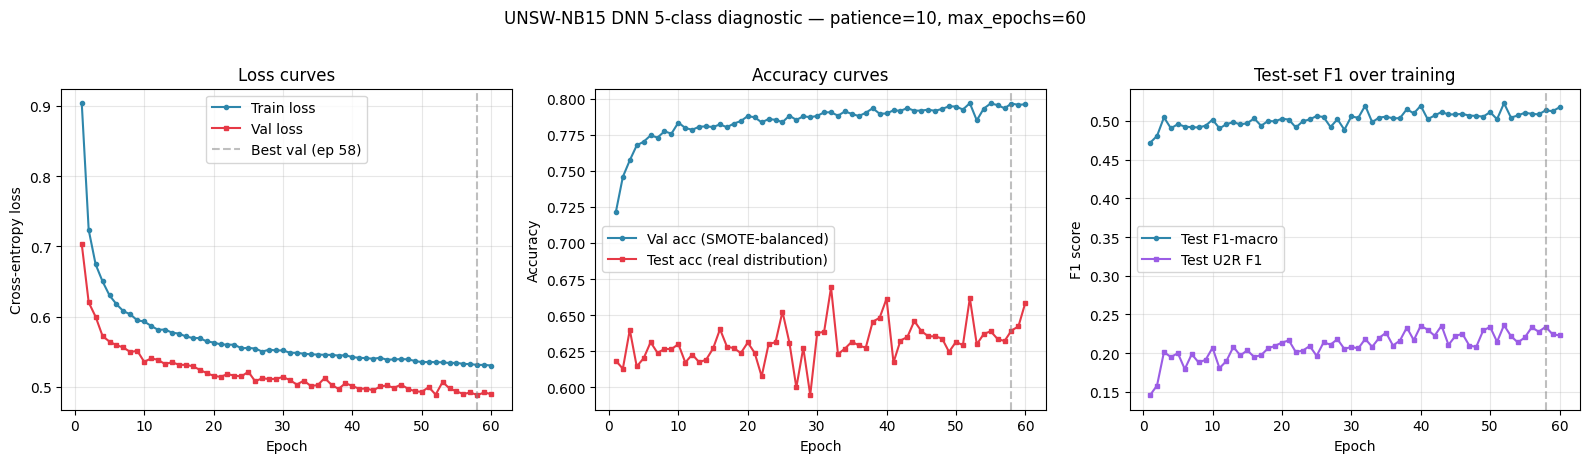

Saved: /content/drive/MyDrive/XIDS_Research/xids-research/results/figures/unsw_dnn_5class_diagnostic.png


In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

ep = history['epoch']

# Panel 1: train vs val loss
axes[0].plot(ep, history['train_loss'], label='Train loss',     marker='o', markersize=3, color='#2E86AB')
axes[0].plot(ep, history['val_loss'],   label='Val loss',       marker='s', markersize=3, color='#E63946')
axes[0].axvline(best_epoch, color='gray', linestyle='--', alpha=0.5, label=f'Best val (ep {best_epoch})')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross-entropy loss')
axes[0].set_title('Loss curves')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Panel 2: val and test accuracy
axes[1].plot(ep, history['val_acc'],  label='Val acc (SMOTE-balanced)',  marker='o', markersize=3, color='#2E86AB')
axes[1].plot(ep, history['test_acc'], label='Test acc (real distribution)', marker='s', markersize=3, color='#E63946')
axes[1].axvline(best_epoch, color='gray', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy curves')
axes[1].legend()
axes[1].grid(alpha=0.3)

# Panel 3: macro F1 and U2R F1 on test
axes[2].plot(ep, history['test_f1_macro'], label='Test F1-macro', marker='o', markersize=3, color='#2E86AB')
axes[2].plot(ep, history['test_u2r_f1'],   label='Test U2R F1',   marker='s', markersize=3, color='#9B5DE5')
axes[2].axvline(best_epoch, color='gray', linestyle='--', alpha=0.5)
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('F1 score')
axes[2].set_title('Test-set F1 over training')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.suptitle(f'UNSW-NB15 DNN 5-class diagnostic — patience={PATIENCE}, max_epochs={EPOCHS}',
             fontsize=12, y=1.02)
plt.tight_layout()

fig_path = REPO / 'results/figures/unsw_dnn_5class_diagnostic.png'
plt.savefig(fig_path, dpi=180, bbox_inches='tight')
plt.show()
print(f'Saved: {fig_path}')

## Automatic diagnosis

In [6]:
# Pull key numbers for diagnosis
epochs_run = len(history['epoch'])

# Compare last 5 vs first-5-after-best-epoch on test F1
if best_epoch + 5 < epochs_run:
    pre_window  = np.mean(history['test_f1_macro'][best_epoch-1:best_epoch+4])
    post_window = np.mean(history['test_f1_macro'][-5:])
    test_f1_drift = post_window - pre_window
else:
    test_f1_drift = 0.0

final_train = history['train_loss'][-1]
final_val   = history['val_loss'][-1]
best_test_f1 = max(history['test_f1_macro'])
best_test_f1_epoch = history['epoch'][np.argmax(history['test_f1_macro'])]
best_u2r_f1 = max(history['test_u2r_f1'])
final_test_f1 = history['test_f1_macro'][-1]
n02_test_f1 = 0.5055  # from Notebook 02 metrics

print('=' * 65)
print('DIAGNOSTIC SUMMARY')
print('=' * 65)
print(f'Epochs run:                       {epochs_run} / {EPOCHS}')
print(f'Best val_loss epoch:              {best_epoch}')
print(f'Best test F1-macro overall:       {best_test_f1:.4f}  (at epoch {best_test_f1_epoch})')
print(f'Best test U2R F1 overall:         {best_u2r_f1:.4f}')
print(f'Final epoch test F1-macro:        {final_test_f1:.4f}')
print(f'Notebook 02 test F1-macro:        {n02_test_f1:.4f}')
print(f'Train loss (final):               {final_train:.4f}')
print(f'Val loss (final):                 {final_val:.4f}')
print(f'Train/val gap (final):            {final_val - final_train:+.4f}')
print('=' * 65)

print('\nDiagnosis:')

diagnoses = []

if best_epoch >= epochs_run - 2 and epochs_run == EPOCHS:
    diagnoses.append('UNDERTRAINING — best val_loss came at the very last epoch. Need more epochs.')

if (final_val - final_train) > 0.15:
    diagnoses.append('OVERFITTING — val loss is materially above train loss at the end. Need regularisation or earlier stop.')

if best_test_f1 > n02_test_f1 + 0.02:
    diagnoses.append(f'POTENTIAL GAIN — peak test F1 ({best_test_f1:.4f}) beats Notebook 02 ({n02_test_f1:.4f}) by >0.02. Worth retraining with the better setup.')

if best_u2r_f1 > 0.30:
    diagnoses.append(f'U2R IS LEARNABLE — peak U2R F1 {best_u2r_f1:.4f} is well above Notebook 02 (0.2200). DNN can do better on rare class with the right stopping epoch.')

if test_f1_drift < -0.02:
    diagnoses.append(f'VAL/TEST DISAGREE — test F1 drifted down after best val_loss epoch (drift={test_f1_drift:+.3f}). Val set isn\'t a good proxy for test under distribution shift.')

if not diagnoses:
    diagnoses.append('NOTHING UNUSUAL — DNN converged normally. The gap to RF/XGB is architectural, not a training issue.')

for d in diagnoses:
    print(f'  • {d}')

print('\nRecommendation will depend on which of the above apply — see notes below.')

DIAGNOSTIC SUMMARY
Epochs run:                       60 / 60
Best val_loss epoch:              58
Best test F1-macro overall:       0.5230  (at epoch 52)
Best test U2R F1 overall:         0.2361
Final epoch test F1-macro:        0.5177
Notebook 02 test F1-macro:        0.5055
Train loss (final):               0.5302
Val loss (final):                 0.4895
Train/val gap (final):            -0.0407

Diagnosis:
  • UNDERTRAINING — best val_loss came at the very last epoch. Need more epochs.

Recommendation will depend on which of the above apply — see notes below.


## How to read the result

**Scenario A — "NOTHING UNUSUAL" or only the U2R note fired:**  
DNN is just architecturally weaker than trees on this data. Keep the current Notebook 02 model, move on to calibration. The cross-dataset story (XGB > RF > DNN on rare classes) is consistent across all three datasets, which strengthens the paper.

**Scenario B — UNDERTRAINING fired:**  
Increase max_epochs to 80, keep patience=10. Retrain just `dnn_5class_smote`.

**Scenario C — OVERFITTING fired:**  
Increase dropout to 0.4 or add weight_decay=1e-4 to Adam. Retrain.

**Scenario D — POTENTIAL GAIN or VAL/TEST DISAGREE fired:**  
Worth a retrain with longer patience. The model has more in it than we extracted.

Paste the diagnostic output to me and I'll tell you which scenario you're in and the exact next step.

**Note:** this diagnostic notebook does NOT overwrite the existing `dnn_5class_smote` model on Drive. It's read-only diagnostic. Any retrain happens in a follow-up step.